Autor יהוה y Kaoru Aguiera Katayama

In [1]:
# ============================================================
# Celda 1: Instalación de dependencias
# Clonamos/instalamos wheels precompiladas => rápido
# ============================================================
import sys, subprocess, os

def sh(cmd):
    print(f"$ {cmd}")
    subprocess.run(cmd, shell=True, check=True)

# Wheels precompiladas (nada de compilar C++ a mano)
sh("pip install -q numpy scipy sympy matplotlib plotly tqdm")
sh("pip install -q ripser persim scikit-learn")
sh("pip install -q gudhi")           # wheel oficial en PyPI
sh("pip install -q pot")             # optimal transport, útil para bottleneck

# Clonamos repos SOLO para tener ejemplos y utilidades extra
if not os.path.exists("/content/ripser"):
    sh("git clone --depth 1 https://github.com/scikit-tda/ripser.py.git /content/ripser")
if not os.path.exists("/content/gudhi-examples"):
    sh("git clone --depth 1 https://github.com/GUDHI/TDA-tutorial.git /content/gudhi-examples")

print("\n✅ Setup listo.")


$ pip install -q numpy scipy sympy matplotlib plotly tqdm
$ pip install -q ripser persim scikit-learn
$ pip install -q gudhi
$ pip install -q pot
$ git clone --depth 1 https://github.com/scikit-tda/ripser.py.git /content/ripser
$ git clone --depth 1 https://github.com/GUDHI/TDA-tutorial.git /content/gudhi-examples

✅ Setup listo.


In [2]:
# ============================================================
# Celda 2: F(x,y) y G(x,y,u,v) tal cual en el paper
#   F(x,y) = (x+y)^2 - x^2 + y^(x - 2/y) + y + x + 2xy + 543
#   G(x,y,u,v) = F(x,y) + u^2 + v^2
# Dominio honesto: y > 0 (para exponenciación real sin ramas)
# ============================================================
import numpy as np
import sympy as sp

x, y, u, v = sp.symbols('x y u v', real=True)

F_sym = (x + y)**2 - x**2 + y**(x - 2/y) + y + x + 2*x*y + 543
G_sym = F_sym + u**2 + v**2

print("F(x,y) =")
sp.pretty_print(sp.simplify(F_sym))
print("\nG(x,y,u,v) = F(x,y) + u^2 + v^2")

# Gradiente simbólico
grad_G_sym = [sp.diff(G_sym, s) for s in (x, y, u, v)]
print("\n∇G =")
for i, g in enumerate(grad_G_sym):
    print(f"  ∂G/∂{['x','y','u','v'][i]} =", sp.simplify(g))

# Versiones numéricas rápidas (lambdify)
F_num    = sp.lambdify((x, y),        F_sym, "numpy")
G_num    = sp.lambdify((x, y, u, v),  G_sym, "numpy")
gradG_num = [sp.lambdify((x, y, u, v), g, "numpy") for g in grad_G_sym]

def G_np(X):
    """X shape (N,4) -> (N,)"""
    return G_num(X[:,0], X[:,1], X[:,2], X[:,3])

def gradG_np(X):
    """X shape (N,4) -> (N,4)"""
    return np.stack([gi(X[:,0], X[:,1], X[:,2], X[:,3]) for gi in gradG_num], axis=1)


F(x,y) =
                          2      
                      x - ─      
             2            y      
4⋅x⋅y + x + y  + y + y      + 543

G(x,y,u,v) = F(x,y) + u^2 + v^2

∇G =
  ∂G/∂x = 4*y + y**(x - 2/y)*log(y) + 1
  ∂G/∂y = (y**2*(4*x + 2*y + 1) + y**((x*y - 2)/y)*(x*y + 2*log(y) - 2))/y**2
  ∂G/∂u = 2*u
  ∂G/∂v = 2*v


F rango finito: [516.02, 87960930222079794334251017546473829167869466145732952064.00]
F mediana: 552.72


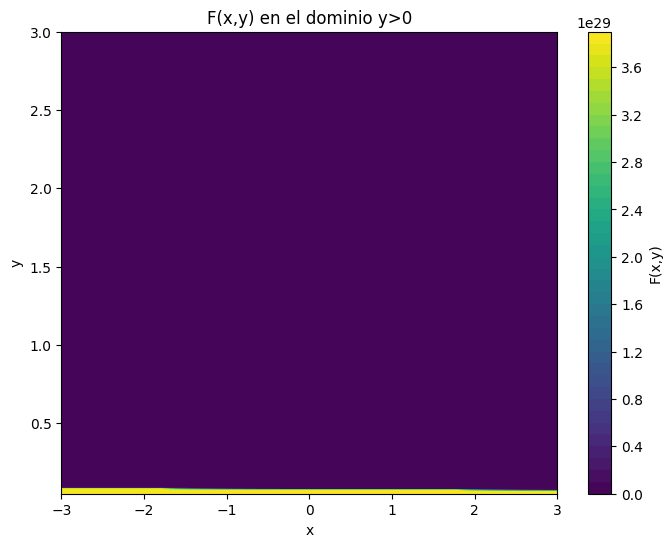


Valores de c a probar: [np.float64(521.0178055502507), np.float64(536.0178055502507), np.float64(616.0178055502507), np.float64(1016.0178055502507)]


In [3]:
# ============================================================
# Celda 3: Explorar F(x,y) en y>0 para elegir c
# ============================================================
import matplotlib.pyplot as plt

xs = np.linspace(-3, 3, 400)
ys = np.linspace(0.05, 3, 400)     # y>0
XX, YY = np.meshgrid(xs, ys)

with np.errstate(all='ignore'):
    FF = F_num(XX, YY)

# Filtrar valores finitos
mask = np.isfinite(FF)
print(f"F rango finito: [{FF[mask].min():.2f}, {FF[mask].max():.2f}]")
print(f"F mediana: {np.median(FF[mask]):.2f}")

plt.figure(figsize=(8,6))
plt.contourf(XX, YY, np.clip(FF, np.percentile(FF[mask],1),
                                     np.percentile(FF[mask],99)), 40, cmap='viridis')
plt.colorbar(label='F(x,y)')
plt.xlabel('x'); plt.ylabel('y'); plt.title('F(x,y) en el dominio y>0')
plt.show()

# G = F + u^2 + v^2 >= F, así que para que G=c tenga solución
# necesitamos c >= min F sobre la región. Elegimos varios c.
Fmin = np.nanmin(FF[mask])
c_values = [Fmin + 5, Fmin + 20, Fmin + 100, Fmin + 500]
print(f"\nValores de c a probar: {c_values}")


In [4]:
# ============================================================
# Celda 4: Muestreo denso de M_{F,c} en R^4
# Estrategia: sembrar puntos aleatorios en una caja 4D,
# proyectar por Newton a G=c, filtrar los que convergen.
# ============================================================
from tqdm import tqdm

def project_to_levelset(X0, c, n_iter=50, tol=1e-8):
    """
    Proyecta puntos X0 (N,4) al level set {G=c} por Newton
    a lo largo del gradiente. Devuelve (X_proy, mask_ok).
    """
    X = X0.copy()
    for _ in range(n_iter):
        with np.errstate(all='ignore'):
            g = G_np(X) - c
            grad = gradG_np(X)
        norm2 = np.sum(grad**2, axis=1)
        # paso Newton: X <- X - g * grad / |grad|^2
        step = (g / np.where(norm2 > 1e-14, norm2, 1e-14))[:, None] * grad
        X = X - step
        # descartar no-finitos
        bad = ~np.isfinite(X).all(axis=1)
        X[bad] = np.nan
    with np.errstate(all='ignore'):
        residual = np.abs(G_np(X) - c)
    ok = np.isfinite(residual) & (residual < 1e-4) & np.isfinite(X).all(axis=1)
    # además exigimos y>0 (dominio real de la exponenciación)
    ok = ok & (X[:,1] > 0.05)
    return X, ok

def sample_levelset(c, n_seeds=20000, box=((-3,3),(0.1,3),(-25,25),(-25,25)),
                    seed=0):
    rng = np.random.default_rng(seed)
    X0 = np.stack([rng.uniform(a,b,n_seeds) for (a,b) in box], axis=1)
    X, ok = project_to_levelset(X0, c)
    pts = X[ok]
    print(f"  c={c:.2f}: {ok.sum()}/{n_seeds} puntos proyectados ({100*ok.mean():.1f}%)")
    return pts

samples = {}
for c in c_values:
    print(f"\n▶ Muestreando level set con c = {c:.2f}")
    pts = sample_levelset(c, n_seeds=15000)
    samples[c] = pts



▶ Muestreando level set con c = 521.02


/tmp/ipykernel_3714/1470955735.py:18: RuntimeWarning: overflow encountered in square
  norm2 = np.sum(grad**2, axis=1)
/tmp/ipykernel_3714/1470955735.py:20: RuntimeWarning: invalid value encountered in divide
  step = (g / np.where(norm2 > 1e-14, norm2, 1e-14))[:, None] * grad


  c=521.02: 9669/15000 puntos proyectados (64.5%)

▶ Muestreando level set con c = 536.02
  c=536.02: 9893/15000 puntos proyectados (66.0%)

▶ Muestreando level set con c = 616.02


/tmp/ipykernel_3714/1470955735.py:20: RuntimeWarning: invalid value encountered in multiply
  step = (g / np.where(norm2 > 1e-14, norm2, 1e-14))[:, None] * grad


  c=616.02: 11299/15000 puntos proyectados (75.3%)

▶ Muestreando level set con c = 1016.02
  c=1016.02: 12836/15000 puntos proyectados (85.6%)


In [6]:
# ============================================================
# Celda 5: ¿Es c un valor regular?  (∇G ≠ 0 sobre M_{F,c})
# ============================================================
for c, pts in samples.items():
    if len(pts) < 10:
        print(f"c={c:.2f}: muy pocos puntos, salto.")
        continue
    grads = gradG_np(pts)
    norms = np.linalg.norm(grads, axis=1)
    print(f"c={c:.2f}: |∇G| min={norms.min():.3e}, "
          f"mediana={np.median(norms):.3e}, max={norms.max():.3e}, "
          f"#pts={len(pts)}")
    if norms.min() > 1e-6:
        print(f"   ✅ c={c:.2f} parece valor regular en la muestra.")
    else:
        print(f"   ⚠️  c={c:.2f} tiene puntos casi-críticos.")


c=521.02: |∇G| min=1.179e+01, mediana=2.330e+01, max=5.157e+01, #pts=9669
   ✅ c=521.02 parece valor regular en la muestra.
c=536.02: |∇G| min=7.491e+00, mediana=2.284e+01, max=5.131e+01, #pts=9893
   ✅ c=536.02 parece valor regular en la muestra.
c=616.02: |∇G| min=1.576e+01, mediana=2.379e+01, max=2.176e+03, #pts=11299
   ✅ c=616.02 parece valor regular en la muestra.
c=1016.02: |∇G| min=4.280e+01, mediana=4.528e+01, max=2.509e+04, #pts=12836
   ✅ c=1016.02 parece valor regular en la muestra.



▶ Homología persistente para c=521.02  (9669 pts)
   Betti estimados (β0,β1,β2) ≈ [np.int64(152), np.int64(7), np.int64(0)]
   Referencia S^3:              (1, 0, 0)  [β3=1 no calculable aquí]


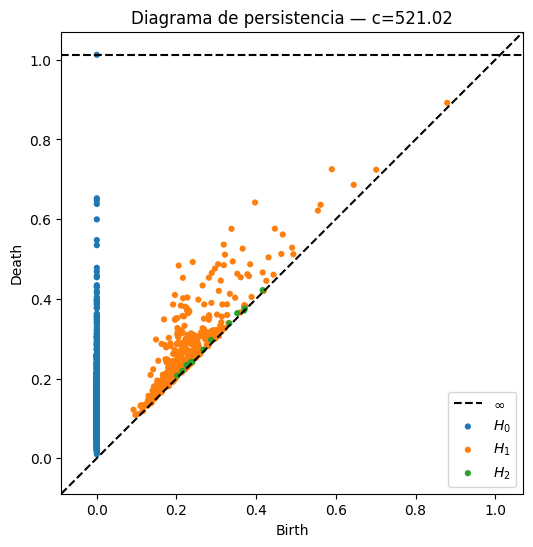


▶ Homología persistente para c=536.02  (9893 pts)
   Betti estimados (β0,β1,β2) ≈ [np.int64(143), np.int64(8), np.int64(0)]
   Referencia S^3:              (1, 0, 0)  [β3=1 no calculable aquí]


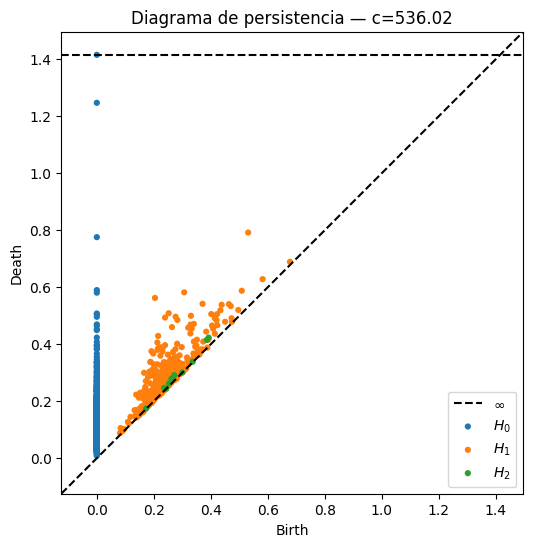


▶ Homología persistente para c=616.02  (11299 pts)
   Betti estimados (β0,β1,β2) ≈ [np.int64(161), np.int64(7), np.int64(0)]
   Referencia S^3:              (1, 0, 0)  [β3=1 no calculable aquí]


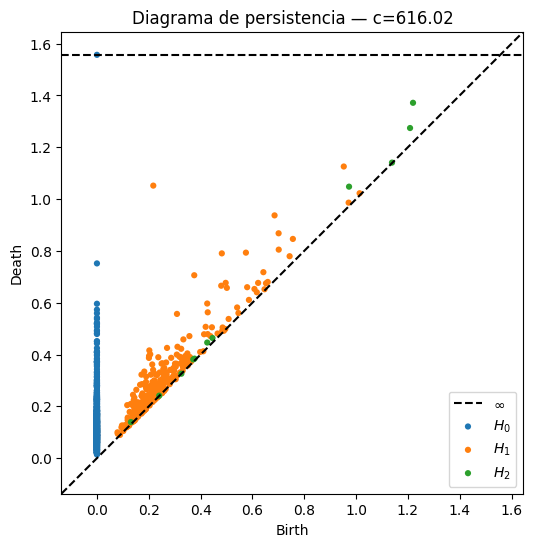


▶ Homología persistente para c=1016.02  (12836 pts)
   Betti estimados (β0,β1,β2) ≈ [np.int64(134), np.int64(9), np.int64(0)]
   Referencia S^3:              (1, 0, 0)  [β3=1 no calculable aquí]


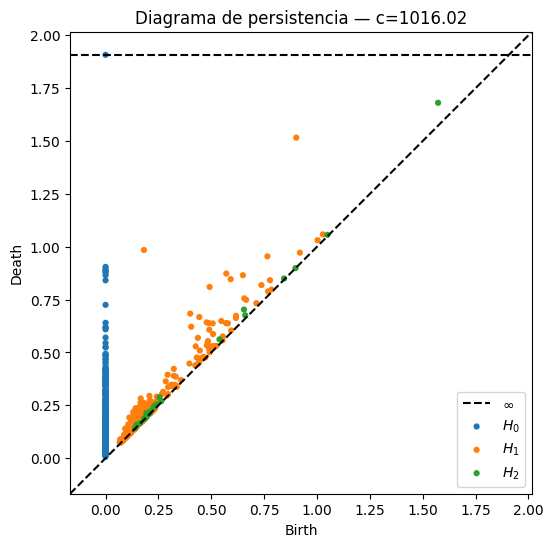

In [7]:
# ============================================================
# Celda 6: Homología persistente con Ripser
# Comparamos Betti (β0, β1, β2) con los de S^3: (1,0,0,1)
# Nota: Ripser calcula H_0, H_1, H_2 (H_3 requiere más caro).
# Pero para distinguir S^3 de otras 3-variedades basta ver β1, β2.
# S^3:   β0=1, β1=0, β2=0, β3=1
# S^2×S^1: β0=1, β1=1, β2=1, β3=1
# T^3:   β0=1, β1=3, β2=3, β3=1
# ============================================================
from ripser import ripser
from persim import plot_diagrams

def subsample(pts, n_max=1500, seed=0):
    """Ripser en 4D con >2000 pts es lento; submuestreamos."""
    if len(pts) <= n_max:
        return pts
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(pts), n_max, replace=False)
    return pts[idx]

def normalize(pts):
    """Centrar y escalar para que los diagramas sean comparables."""
    p = pts - pts.mean(0)
    s = np.std(p)
    return p / (s + 1e-12)

def betti_from_diagram(dgms, persistence_threshold=0.15):
    """Cuenta features cuya persistencia supera el umbral."""
    betti = []
    for k, dgm in enumerate(dgms):
        if len(dgm) == 0:
            betti.append(0); continue
        # eliminar puntos en infinito para conteo finito, pero H_0 tendrá 1
        finite = dgm[np.isfinite(dgm[:,1])]
        infinite = len(dgm) - len(finite)
        persistent = np.sum((finite[:,1] - finite[:,0]) > persistence_threshold) if len(finite) else 0
        betti.append(persistent + infinite)
    return betti

results = {}
for c, pts in samples.items():
    if len(pts) < 100:
        print(f"c={c:.2f}: pts insuficientes, salto.")
        continue
    print(f"\n▶ Homología persistente para c={c:.2f}  ({len(pts)} pts)")
    P = normalize(subsample(pts, n_max=1200))
    res = ripser(P, maxdim=2, thresh=3.0)
    dgms = res['dgms']
    betti = betti_from_diagram(dgms, persistence_threshold=0.20)
    results[c] = (dgms, betti)
    print(f"   Betti estimados (β0,β1,β2) ≈ {betti}")
    print(f"   Referencia S^3:              (1, 0, 0)  [β3=1 no calculable aquí]")

    fig, ax = plt.subplots(figsize=(6,6))
    plot_diagrams(dgms, show=False, ax=ax)
    ax.set_title(f"Diagrama de persistencia — c={c:.2f}")
    plt.show()


In [10]:
# ============================================================
# Celda 7: ¿π_1 = 0?  Aproximación: β_1 = 0.
# (β_1 = 0 no implica π_1=0 en general, pero β_1 > 0 sí implica π_1 ≠ 0.)
# Y comparamos con Betti de S^3.
# ============================================================
print("="*70)
print(f"{'c':>10} | {'β0':>4} {'β1':>4} {'β2':>4} | ¿compatible con S^3?")
print("-"*70)
for c, (dgms, betti) in results.items():
    b0, b1, b2 = betti
    compat_s3 = (b0 == 1 and b1 == 0 and b2 == 0)
    verdict = "SÍ ✅" if compat_s3 else "NO ❌"
    print(f"{c:>10.2f} | {b0:>4} {b1:>4} {b2:>4} | {verdict}")
print("="*70)


         c |   β0   β1   β2 | ¿compatible con S^3?
----------------------------------------------------------------------
    521.02 |  152    7    0 | NO ❌
    536.02 |  143    8    0 | NO ❌
    616.02 |  161    7    0 | NO ❌
   1016.02 |  134    9    0 | NO ❌


c=521.02: bbox=[[-10.49   1.16 -12.6  -11.94], [-2.49  8.47 11.8  12.14]], diam≈35.95, #pts=9669
c=536.02: bbox=[[-10.31   0.88 -12.83 -11.97], [-1.45  8.37 12.04 12.26]], diam≈36.60, #pts=9893
c=616.02: bbox=[[ -9.34   0.31 -14.13 -13.81], [ 7.12  7.85 13.48 13.63]], diam≈42.93, #pts=11299
c=1016.02: bbox=[[ -8.95   0.26 -25.53 -22.67], [35.18 32.82 24.12 23.79]], diam≈87.36, #pts=12836


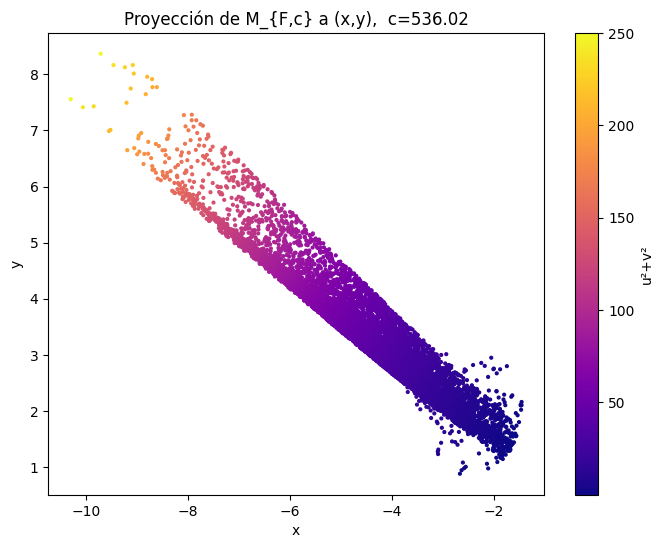

In [9]:
# ============================================================
# Celda 8: ¿Está acotado M_{F,c}?  (Poincaré requiere cerrado=compacto+sin borde)
# ============================================================
for c, pts in samples.items():
    if len(pts) < 50: continue
    mins = pts.min(0); maxs = pts.max(0)
    diam = np.linalg.norm(maxs - mins)
    print(f"c={c:.2f}: bbox=[{mins.round(2)}, {maxs.round(2)}], diam≈{diam:.2f}, #pts={len(pts)}")

# Visualización 2D: proyección (x, y) coloreada por u^2+v^2
c0 = c_values[1]
pts = samples[c0]
plt.figure(figsize=(8,6))
sc = plt.scatter(pts[:,0], pts[:,1], c=pts[:,2]**2+pts[:,3]**2,
                 s=4, cmap='plasma')
plt.colorbar(sc, label='u²+v²')
plt.xlabel('x'); plt.ylabel('y')
plt.title(f'Proyección de M_{{F,c}} a (x,y),  c={c0:.2f}')
plt.show()
